In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import ReLU
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pyhere

In [2]:
train_path = pyhere.here('Data', 'train_data.xlsx')
test_path = pyhere.here('Data', 'test_data.xlsx')
train_data = pd.read_excel(train_path)
test_data = pd.read_excel(test_path)
# Use dropna() to remove any rows with missing values
train_data = train_data.dropna()
test_data = test_data.dropna()
print(train_data.head())

            CountryName CountryCode  year  HDI_Index  \
0   Antigua and Barbuda         ATG  2022      0.848   
9   Antigua and Barbuda         ATG  2008      0.830   
10  Antigua and Barbuda         ATG  2009      0.827   
11  Antigua and Barbuda         ATG  2010      0.828   
12  Antigua and Barbuda         ATG  2011      0.828   

                   HDI_Category  FoodIndex  ElectricAccess  PopDensity  \
0   Very high human development      89.95           100.0  211.000000   
9   Very high human development     145.98           100.0  188.436364   
10  Very high human development     141.40            98.5  191.302273   
11  Very high human development     102.49            98.7  193.909091   
12  Very high human development     104.99            94.6  196.209091   

    PopInSlums  WaterStress  ...  IncomeGroup  YearlyChgInternet  \
0     2.646340     8.461538  ...  High income           0.997844   
9     2.646317     9.230769  ...  High income           3.164091   
10    2.646311

In [3]:
train_target = train_data['HDI_Index']
test_target = test_data['HDI_Index']

train_predictors = train_data.drop('HDI_Index', axis=1)
test_predictors = test_data.drop('HDI_Index', axis=1)

train_predictors = train_data[['CountryCode', 'FoodIndex', 'ElectricAccess', 'PopDensity', 'PopInSlums', 'WaterStress', 'InternetUsersPct', 
                               'GDPPerCapGrowth', 'GDPGrowth', 'GDP', 'PoliticalStability', 'RqdEduYears', 'GovtEduSpendPctGDP', 
                               'UHCServiceCoverage', 'RuralPopulGrowth', 'VoiceAccountability']]

test_predictors = test_data[['CountryCode', 'FoodIndex', 'ElectricAccess', 'PopDensity', 'PopInSlums', 'WaterStress', 'InternetUsersPct', 
                             'GDPPerCapGrowth', 'GDPGrowth', 'GDP', 'PoliticalStability', 'RqdEduYears', 'GovtEduSpendPctGDP', 
                             'UHCServiceCoverage', 'RuralPopulGrowth', 'VoiceAccountability']]


In [4]:
# Combine the predictor data frames to ensure consistent encoding
combined_predictors = pd.concat([train_predictors, test_predictors], ignore_index=True)

# Identify numerical and categorical columns
numerical_cols = combined_predictors.select_dtypes(include=np.number).columns
categorical_cols = combined_predictors.select_dtypes(include='object').columns

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the combined numerical data to learn the min/max values
combined_predictors[numerical_cols] = scaler.fit_transform(combined_predictors[numerical_cols])

# Initialize OneHotEncoder to create sparse output and handle unknown categories
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit the encoder on the combined data to learn all possible categories
combined_categorical_encoded = ohe.fit_transform(combined_predictors[categorical_cols])

# Combine the encoded categorical data with the numerical data
combined_features = np.concatenate([combined_predictors[numerical_cols].values, 
                                    combined_categorical_encoded], axis=1)

# Split the combined feature matrix back into training and test sets
train_features = combined_features[:len(train_predictors)]
test_features = combined_features[len(train_predictors):]

# Features split

train_features, test_features, train_target, test_target = train_test_split(
    combined_features, train_target, test_size=0.2, random_state=42)




--- Training Model with Tanh and RMSProp---
Epoch 1/1000


C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0999 - mae: 0.2042 - val_loss: 0.0256 - val_mae: 0.1461
Epoch 2/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0155 - mae: 0.1005 - val_loss: 0.0160 - val_mae: 0.1180
Epoch 3/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0091 - mae: 0.0815 - val_loss: 0.0184 - val_mae: 0.1274
Epoch 4/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0052 - mae: 0.0599 - val_loss: 0.0012 - val_mae: 0.0280
Epoch 5/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0054 - mae: 0.0581 - val_loss: 0.0123 - val_mae: 0.1057
Epoch 6/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043 - mae: 0.0558 - val_loss: 0.0030 - val_mae: 0.0477
Epoch 7/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - mae: 0.0496 - val_loss: 0.0061 - val_mae: 0.0735
Epoch 8/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - mae: 0.0461 - val_loss: 0.0058 - val_mae: 0.0720
Epoch 9/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - 

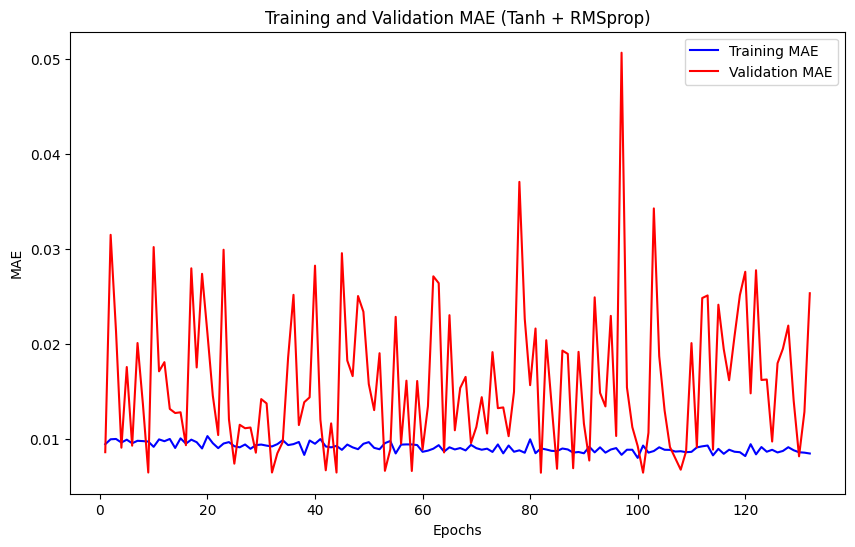

In [5]:
print("\n--- Training Model with Tanh and RMSProp---")
model_tanh_rms = Sequential()
model_tanh_rms.add(Dense(256, input_dim=train_features.shape[1], activation='tanh'))
model_tanh_rms.add(Dense(128, activation='tanh'))
model_tanh_rms.add(Dense(64, activation='tanh'))
model_tanh_rms.add(Dense(1, activation='linear'))

model_tanh_rms.compile(optimizer=RMSprop(learning_rate=0.001), loss="mse", metrics=["mae"])

# Define early stopping
early_stop_tanh = EarlyStopping(monitor='val_loss', patience=50, verbose=1, restore_best_weights=True)

model_tanh_rms.fit(train_features, train_target,
                    epochs=1000,
                    batch_size=32,
                    validation_data=(test_features, test_target),
                    callbacks=[early_stop_tanh],
                    verbose=1)

loss_tanh_rms =model_tanh_rms.evaluate(test_features, test_target, verbose=0)

history_tanh = model_tanh_rms.fit(train_features, train_target,
                    epochs=1000,
                    batch_size=32,
                    validation_split=0.1,
                    callbacks=[early_stop_tanh],
                    verbose=1)

tanh_results = model_tanh_rms.evaluate(test_features, test_target, verbose=0)
print("Raw evaluate results:", tanh_results)

# Plot the training and validation MAE
mae_tanh = history_tanh.history['mae']
val_mae_tanh = history_tanh.history['val_mae']
epochs = range(1, len(mae_tanh) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, mae_tanh, 'b', label='Training MAE')
plt.plot(epochs, val_mae_tanh, 'r', label='Validation MAE')
plt.title('Training and Validation MAE (Tanh + RMSprop)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()




15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


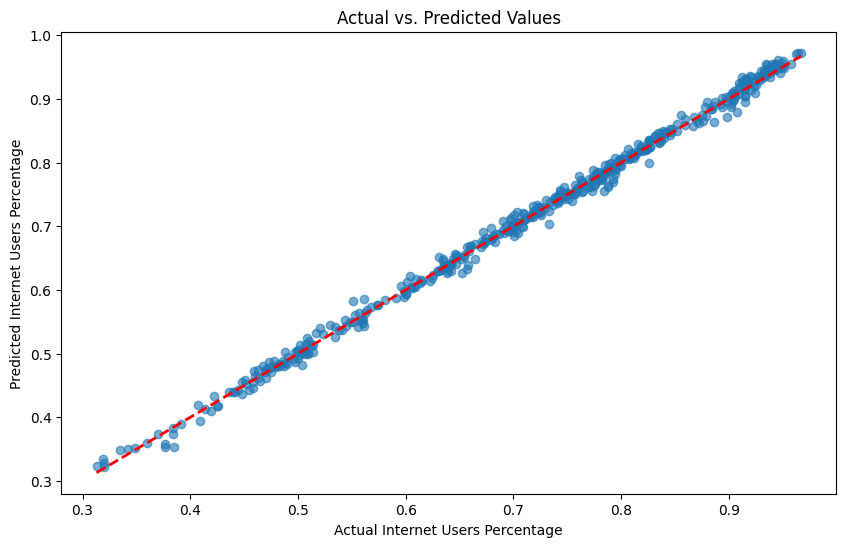

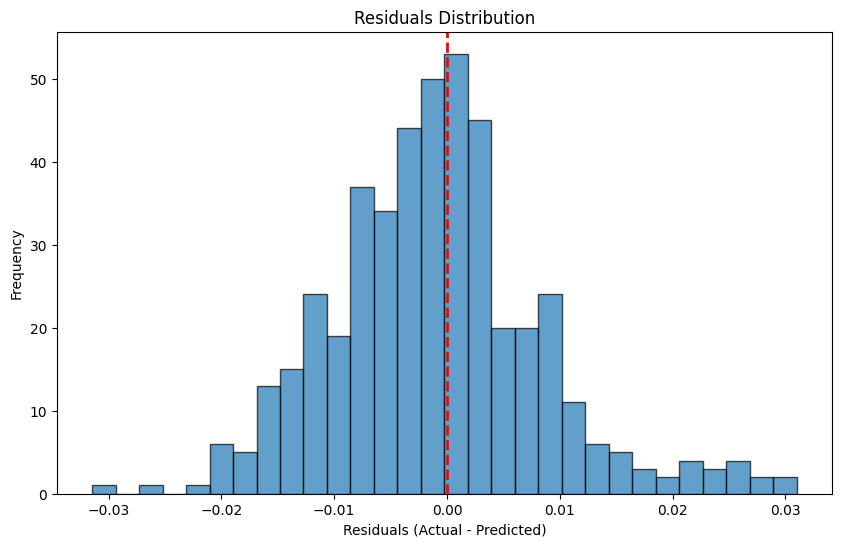

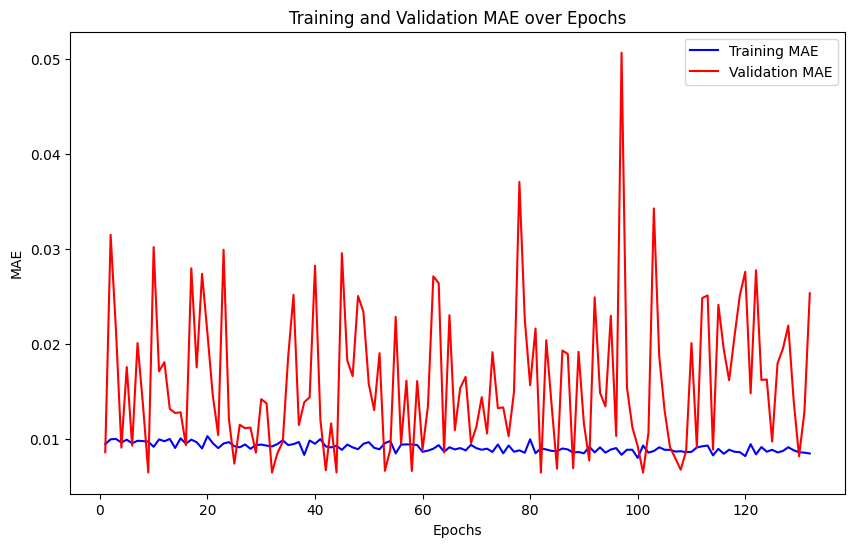

In [6]:
# Predictions and Plots
predictions = model_tanh_rms.predict(test_features)

if not np.any(np.isnan(predictions)):
    predictions = predictions.flatten()
    final_tanh_results = pd.DataFrame({'Actual': test_target, 'Predicted': predictions})

    # Scatter plot: Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(final_tanh_results['Actual'], final_tanh_results['Predicted'], alpha=0.6)
    plt.plot([min(final_tanh_results['Actual']), max(final_tanh_results['Actual'])],
             [min(final_tanh_results['Actual']), max(final_tanh_results['Actual'])],
             color='red', linestyle='--', lw=2)
    plt.title('Actual vs. Predicted Values')
    plt.xlabel('Actual Internet Users Percentage')
    plt.ylabel('Predicted Internet Users Percentage')
    plt.show()

    # Residual plot
    final_tanh_results['Residuals'] = final_tanh_results['Actual'] - final_tanh_results['Predicted']
    plt.figure(figsize=(10, 6))
    plt.hist(final_tanh_results['Residuals'], bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(x=0, color='red', linestyle='--', lw=2)
    plt.title('Residuals Distribution')
    plt.xlabel('Residuals (Actual - Predicted)')
    plt.ylabel('Frequency')
    plt.show()

    # Training & validation MAE
    mae_history = history_tanh.history['mae']
    val_mae_history = history_tanh.history['val_mae']
    epochs_range = range(1, len(mae_history) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, mae_history, 'b', label='Training MAE')
    plt.plot(epochs_range, val_mae_history, 'r', label='Validation MAE')
    plt.title('Training and Validation MAE over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.show()

else:
    print("Predictions contain invalid values (NaN or infinity). Cannot plot.")




--- Training Model with Sigmoid and SGD ---
Epoch 1/1000


C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0266 - mae: 0.1301 - val_loss: 0.0241 - val_mae: 0.1278
Epoch 2/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0227 - mae: 0.1255 - val_loss: 0.0241 - val_mae: 0.1293
Epoch 3/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0227 - mae: 0.1261 - val_loss: 0.0240 - val_mae: 0.1292
Epoch 4/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0226 - mae: 0.1262 - val_loss: 0.0240 - val_mae: 0.1286
Epoch 5/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0226 - mae: 0.1258 - val_loss: 0.0239 - val_mae: 0.1286
Epoch 6/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0225 - mae: 0.1257 - val_loss: 0.0239 - val_mae: 0.1287
Epoch 7/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0225 - mae: 0.1256 - val_loss: 0.0238 - val_mae: 0.1284
Epoch 8/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0224 - mae: 0.1256 - val_loss: 0.0238 - val_mae: 0.1280
Epoch 9/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0224 - 

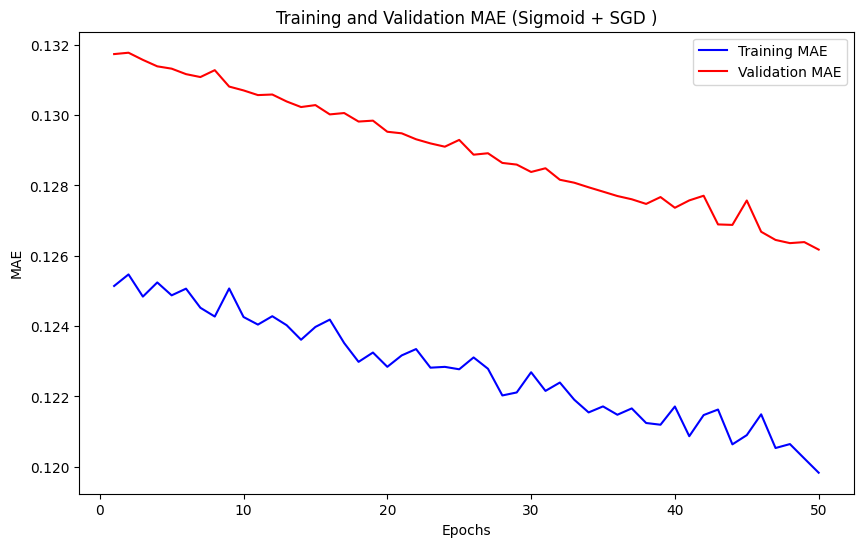

In [7]:
print("\n--- Training Model with Sigmoid and SGD ---")
model_sig = Sequential()
model_sig.add(Dense(256, input_dim=train_features.shape[1], activation='tanh'))
model_sig.add(Dense(128, activation='sigmoid'))
model_sig.add(Dense(64, activation='sigmoid'))
model_sig.add(Dense(1, activation='linear'))

model_sig.compile(optimizer=SGD(learning_rate=0.001), loss="mse", metrics=["mae"])

# Define early stopping
early_stop_sig = EarlyStopping(monitor='val_loss', patience=50, verbose=1, restore_best_weights=True)

model_sig.fit(train_features, train_target,
                    epochs=1000,
                    batch_size=32,
                    validation_data=(test_features, test_target),
                    callbacks=[early_stop_tanh],
                    verbose=1)

loss_sig = model_sig.evaluate(test_features, test_target, verbose=0)

history_sig = model_sig.fit(train_features, train_target,
                    epochs=1000,
                    batch_size=32,
                    validation_split=0.1,
                    callbacks=[early_stop_tanh],
                    verbose=1)

sig_results = model_sig.evaluate(test_features, test_target, verbose=0)
print("Raw evaluate results:", sig_results)

# Plot the training and validation MAE
mae_sig = history_sig.history['mae']
val_mae_sig = history_sig.history['val_mae']
epochs = range(1, len(mae_sig) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, mae_sig, 'b', label='Training MAE')
plt.plot(epochs, val_mae_sig, 'r', label='Validation MAE')
plt.title('Training and Validation MAE (Sigmoid + SGD )')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


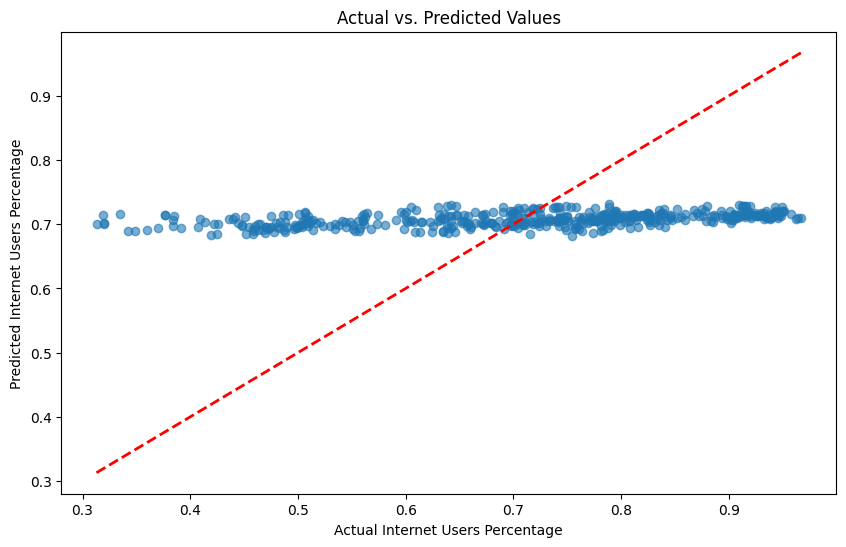

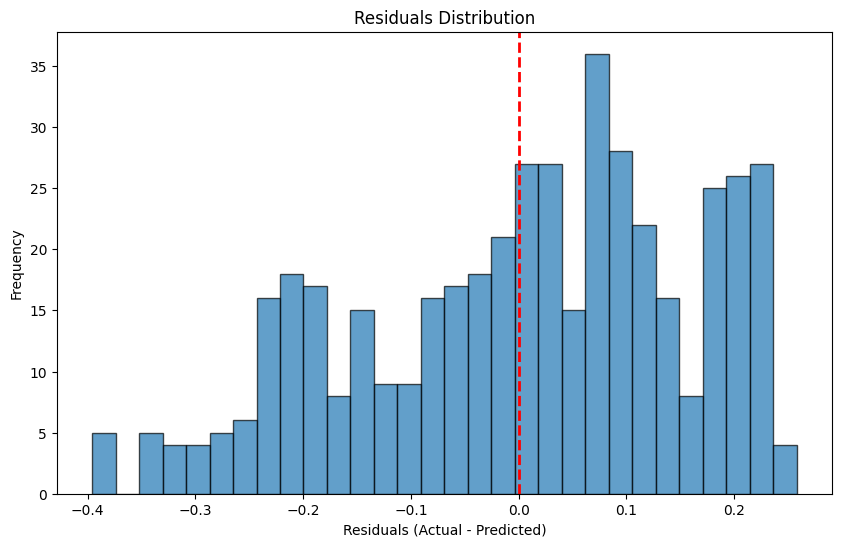

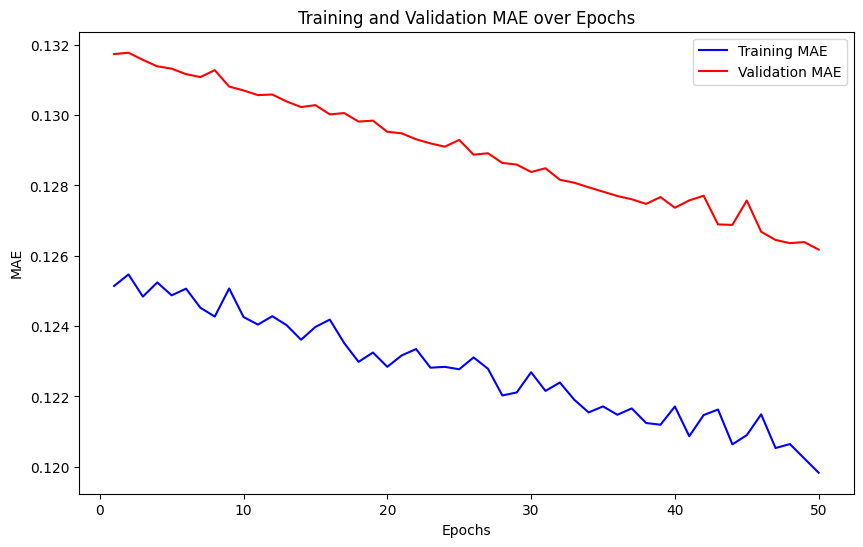

In [8]:
# Predictions and Plots
sig_predictions = model_sig.predict(test_features)

if not np.any(np.isnan(sig_predictions)):
    predictions = sig_predictions.flatten()
    final_sig_results = pd.DataFrame({'Actual': test_target, 'Predicted': predictions})

    # Scatter plot: Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(final_sig_results['Actual'],final_sig_results['Predicted'], alpha=0.6)
    plt.plot([min(final_sig_results['Actual']), max(final_sig_results['Actual'])],
             [min(final_sig_results['Actual']), max(final_sig_results['Actual'])],
             color='red', linestyle='--', lw=2)
    plt.title('Actual vs. Predicted Values')
    plt.xlabel('Actual Internet Users Percentage')
    plt.ylabel('Predicted Internet Users Percentage')
    plt.show()

    # Residual plot
    final_sig_results['Residuals'] = final_sig_results['Actual'] - final_sig_results['Predicted']
    plt.figure(figsize=(10, 6))
    plt.hist(final_sig_results['Residuals'], bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(x=0, color='red', linestyle='--', lw=2)
    plt.title('Residuals Distribution')
    plt.xlabel('Residuals (Actual - Predicted)')
    plt.ylabel('Frequency')
    plt.show()

    # Training & validation MAE
    mae_sig = history_sig.history['mae']
    val_mae__sig_history = history_sig.history['val_mae']
    epochs_range = range(1, len(mae_sig) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, mae_sig, 'b', label='Training MAE')
    plt.plot(epochs_range, val_mae__sig_history, 'r', label='Validation MAE')
    plt.title('Training and Validation MAE over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.show()

else:
    print("Predictions contain invalid values (NaN or infinity). Cannot plot.")



--- Training Model with ReLu and Adam ---
Epoch 1/1000


C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0336 - mae: 0.1104 - val_loss: 0.0015 - val_mae: 0.0289
Epoch 2/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.6061e-04 - mae: 0.0204 - val_loss: 4.8282e-04 - val_mae: 0.0159
Epoch 3/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.3293e-04 - mae: 0.0137 - val_loss: 3.3449e-04 - val_mae: 0.0130
Epoch 4/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5468e-04 - mae: 0.0120 - val_loss: 2.7399e-04 - val_mae: 0.0117
Epoch 5/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2276e-04 - mae: 0.0113 - val_loss: 2.4346e-04 - val_mae: 0.0114
Epoch 6/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0208e-04 - mae: 0.0108 - val_loss: 2.2153e-04 - val_mae: 0.0108
Epoch 7/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7180e-04 - mae: 0.0099 - val_loss: 1.7933e-04 - val_mae: 0.0099
Epoch 8/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5951e-04 - mae: 0.0095 - val_loss: 1.7351e-04 - val_mae: 0.0096
Epoch 9/1000


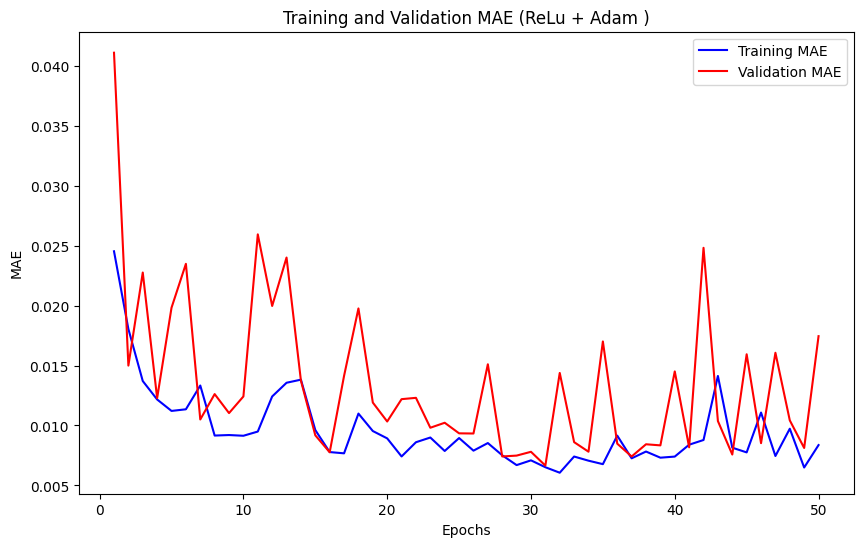

In [9]:
print("\n--- Training Model with ReLu and Adam ---")
model_relu = Sequential()
model_relu.add(Dense(256, input_dim=train_features.shape[1], activation='relu'))
model_relu.add(Dense(128, activation='relu'))
model_relu.add(Dense(64, activation='relu'))
model_relu.add(Dense(1, activation='linear'))

model_relu.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

# Define early stopping
early_stop_relu = EarlyStopping(monitor='val_loss', patience=50, verbose=1, restore_best_weights=True)

model_relu.fit(train_features, train_target,
                    epochs=1000,
                    batch_size=32,
                    validation_data=(test_features, test_target),
                    callbacks=[early_stop_tanh],
                    verbose=1)

loss_relu = model_relu.evaluate(test_features, test_target, verbose=0)

history_relu = model_relu.fit(train_features, train_target,
                    epochs=1000,
                    batch_size=32,
                    validation_split=0.1,
                    callbacks=[early_stop_tanh],
                    verbose=1)

relu_results = model_relu.evaluate(test_features, test_target, verbose=0)
print("Raw evaluate results:", relu_results)

# Plot the training and validation MAE
mae_relu = history_relu.history['mae']
val_mae_relu = history_relu.history['val_mae']
epochs = range(1, len(mae_relu) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, mae_relu, 'b', label='Training MAE')
plt.plot(epochs, val_mae_relu, 'r', label='Validation MAE')
plt.title('Training and Validation MAE (ReLu + Adam )')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


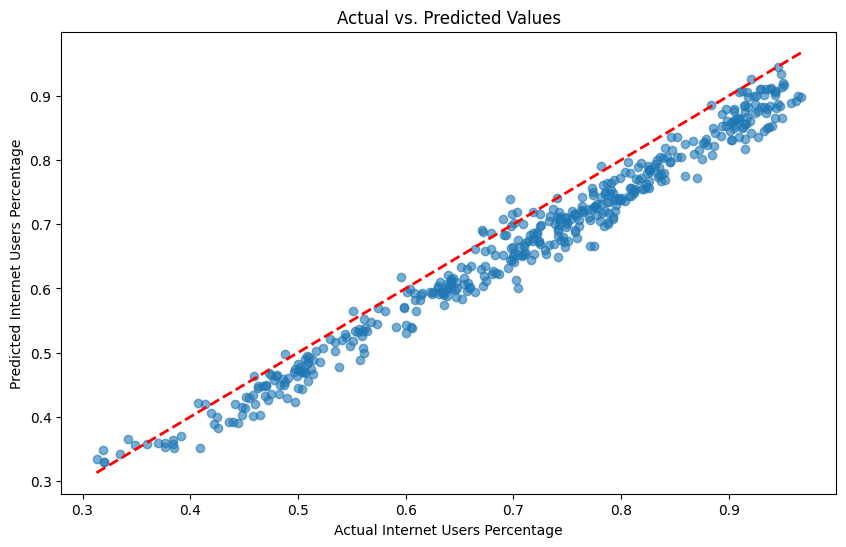

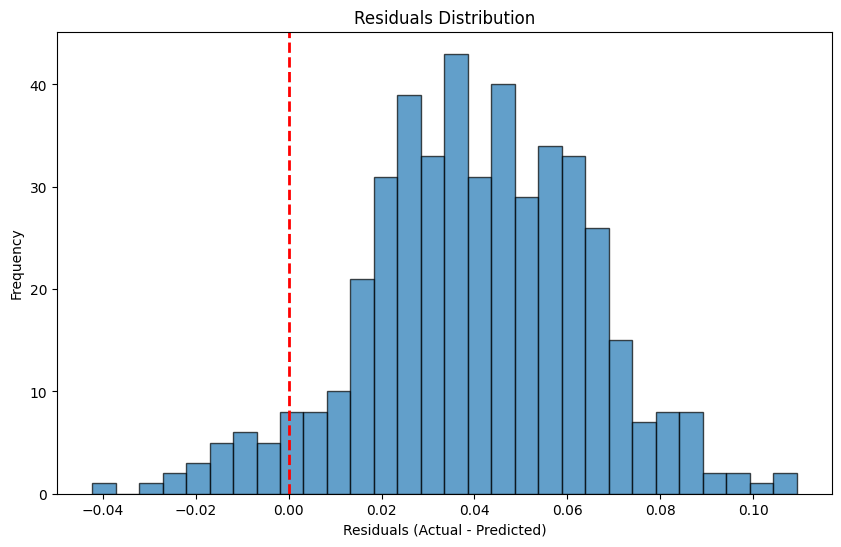

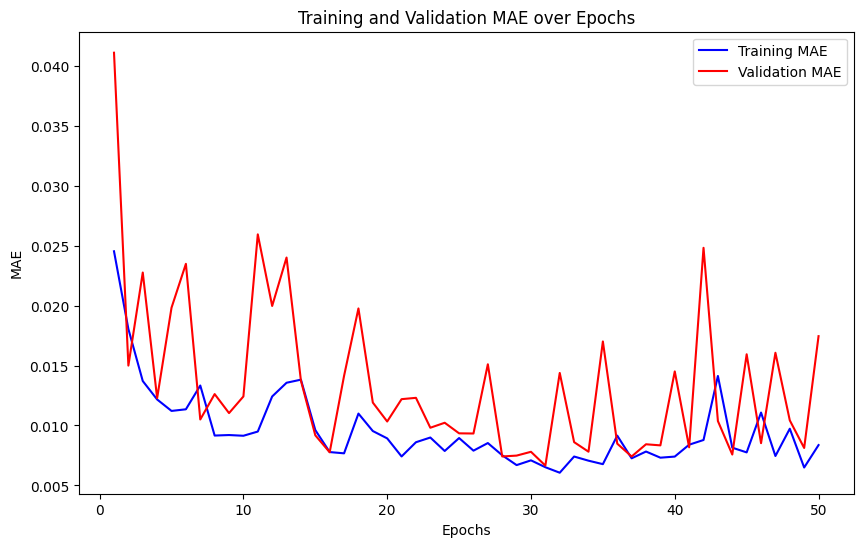

In [10]:
# Predictions and Plots
relu_predictions = model_relu.predict(test_features)

if not np.any(np.isnan(relu_predictions)):
    predictions = relu_predictions.flatten()
    final_relu_results = pd.DataFrame({'Actual': test_target, 'Predicted': predictions})

    # Scatter plot: Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(final_relu_results['Actual'],final_relu_results['Predicted'], alpha=0.6)
    plt.plot([min(final_relu_results['Actual']), max(final_relu_results['Actual'])],
             [min(final_relu_results['Actual']), max(final_relu_results['Actual'])],
             color='red', linestyle='--', lw=2)
    plt.title('Actual vs. Predicted Values')
    plt.xlabel('Actual Internet Users Percentage')
    plt.ylabel('Predicted Internet Users Percentage')
    plt.show()

    # Residual plot
    final_relu_results['Residuals'] = final_relu_results['Actual'] - final_relu_results['Predicted']
    plt.figure(figsize=(10, 6))
    plt.hist(final_relu_results['Residuals'], bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(x=0, color='red', linestyle='--', lw=2)
    plt.title('Residuals Distribution')
    plt.xlabel('Residuals (Actual - Predicted)')
    plt.ylabel('Frequency')
    plt.show()

    # Training & validation MAE
    mae_relu = history_relu.history['mae']
    val_mae__relu_history = history_relu.history['val_mae']
    epochs_range = range(1, len(mae_sig) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, mae_relu, 'b', label='Training MAE')
    plt.plot(epochs_range, val_mae__relu_history, 'r', label='Validation MAE')
    plt.title('Training and Validation MAE over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.show()

else:
    print("Predictions contain invalid values (NaN or infinity). Cannot plot.")


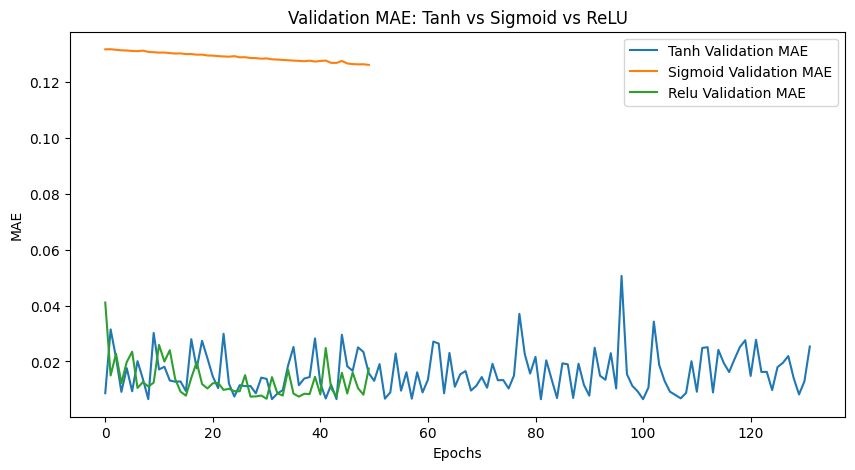

In [11]:
plt.figure(figsize=(10,5))
plt.plot(history_tanh.history['val_mae'], label="Tanh Validation MAE")
plt.plot(history_sig.history['val_mae'], label="Sigmoid Validation MAE")
plt.plot(history_relu.history['val_mae'], label="Relu Validation MAE")
plt.title("Validation MAE: Tanh vs Sigmoid vs ReLU")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()